# 🌿 Assignment 2: Mastering Big Data Handling
#### Group: Sayur
#### Dataset: [Pakistan Carbon monoxide 2022 - 2025](https://www.kaggle.com/datasets/muhammadbilal77511/pakistan-carbon-monoxide-2022-2025)


# 1. Setup

## 1.1 Import Required Libraries

In [ ]:
import pandas as pd
import os
import psutil
import time
import threading
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import gc
import tracemalloc

## 1.2 Upload / Mount Dataset

#####Upload kaggle.json authentication file




In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bomi320","key":"ce7e1a0eb5568e905c1f65e4537136f5"}'}

#####Move to correct location

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

##### Dowload dataset from Kaggle

In [ ]:
!kaggle datasets download -d muhammadbilal77511/pakistan-carbon-monoxide-2022-2025

Dataset URL: https://www.kaggle.com/datasets/muhammadbilal77511/pakistan-carbon-monoxide-2022-2025
License(s): Attribution 4.0 International (CC BY 4.0)
100% 855M/855M [00:40<00:00, 21.9MB/s]



#####Unzip the file

In [ ]:
!unzip pakistan-carbon-monoxide-2022-2025.zip

Archive:  pakistan-carbon-monoxide-2022-2025.zip
  inflating: co_data/processed/year_2022.csv  
  inflating: co_data/processed/year_2023.csv  
  inflating: co_data/processed/year_2024.csv  
  inflating: co_data/processed/year_2025.csv  


## 1.3 Install Additional Libraries (Dask, Polars if needed)

In [ ]:
import dask.dataframe as dd
import polars as pl

# 2. Dataset Introduction

## 2.1 Dataset Source

### This dataset from [Pakistan Carbon monoxide 2022 - 2025](https://www.kaggle.com/datasets/muhammadbilal77511/pakistan-carbon-monoxide-2022-2025)

## 2.2 Dataset Size

In [ ]:
files = [
    "/content/co_data/processed/year_2024.csv",
    "/content/co_data/processed/year_2025.csv"
]

total_size_bytes = 0

for file_path in files:
    size_bytes = os.path.getsize(file_path)
    size_mb = size_bytes / (1024 * 1024)
    size_gb = size_bytes / (1024 * 1024 * 1024)

    total_size_bytes += size_bytes

    print(f"{file_path}")
    print(f"Size: {size_bytes} bytes")
    print(f"Size: {size_mb:.2f} MB")
    print(f"Size: {size_gb:.2f} GB\n")

# Total size
total_size_mb = total_size_bytes / (1024 * 1024)
total_size_gb = total_size_bytes / (1024 * 1024 * 1024)

print("===== TOTAL DATASET SIZE =====")
print(f"Total Size: {total_size_bytes} bytes")
print(f"Total Size: {total_size_mb:.2f} MB")
print(f"Total Size: {total_size_gb:.2f} GB")

/content/co_data/processed/year_2024.csv
Size: 817161775 bytes
Size: 779.31 MB
Size: 0.76 GB

/content/co_data/processed/year_2025.csv
Size: 869961590 bytes
Size: 829.66 MB
Size: 0.81 GB

===== TOTAL DATASET SIZE =====
Total Size: 1687123365 bytes
Total Size: 1608.97 MB
Total Size: 1.57 GB


## 2.3 Number of Rows and Columns

In [ ]:

def count_rows(file_path):
    with open(file_path, "r") as f:
        return sum(1 for _ in f) - 1  # minus header

def get_columns(file_path):
    df = pd.read_csv(file_path, nrows=0)
    return len(df.columns)

total_rows = 0

for file_path in files:
    rows = count_rows(file_path)
    cols = get_columns(file_path)

    total_rows += rows

    print(file_path)
    print("Rows:", rows, "Columns:", cols, "\n")

print("===== TOTAL =====")
print("Total Rows:", total_rows)

/content/co_data/processed/year_2024.csv
Rows: 8939142 Columns: 9 

/content/co_data/processed/year_2025.csv
Rows: 9487238 Columns: 9 

===== TOTAL =====
Total Rows: 18426380


# 3. Initial Data Loading

## 3.1 Load Full Dataset using Pandas

##### Combine separate CSV files into 1 dataset


In [ ]:
combined_df = pd.concat([pd.read_csv(f, low_memory=True) for f in files], ignore_index=True)

## 3.2 Display First 5 Rows

In [ ]:
combined_df.head()

,date,latitude,longitude,co_column,co_quality,year,month,day,day_of_week
0,2024-01-01,23.690218,73.982162,0.053744,1.0,2024,1,1,0
1,2024-01-01,23.691870,69.942146,0.039776,1.0,2024,1,1,0
2,2024-01-01,23.692059,70.382019,0.040581,1.0,2024,1,1,0
3,2024-01-01,23.692949,72.901031,0.046814,0.7,2024,1,1,0
4,2024-01-01,23.698761,70.938744,0.042255,0.7,2024,1,1,0


## 3.3 Check Shape of Dataset

In [ ]:
combined_df.shape
print(f"Rows: {combined_df.shape[0]}, Columns: {combined_df.shape[1]}")

Rows: 18426380, Columns: 9


## 3.4 Check Column Name and Data Types

In [ ]:
print("===== Column Names and Datatypes =====")
combined_df.info()

===== Column Names and Datatypes =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18426380 entries, 0 to 18426379
Data columns (total 9 columns):
 #   Column       Dtype  
---  ------       -----  
 0   date         object 
 1   latitude     float64
 2   longitude    float64
 3   co_column    float64
 4   co_quality   float64
 5   year         int64  
 6   month        int64  
 7   day          int64  
 8   day_of_week  int64  
dtypes: float64(4), int64(4), object(1)
memory usage: 1.2+ GB


## 3.5 Check Missing Values

In [ ]:
total_missing = combined_df.isnull().sum().sum()
total_cells = combined_df.shape[0] * combined_df.shape[1]

print("Total Missing Values:", total_missing)
print("Overall Missing %:", (total_missing / total_cells) * 100)

Total Missing Values: 0
Overall Missing %: 0.0


## 3.6 Initial Memory Usage

In [ ]:
process = psutil.Process(os.getpid())

memory_bytes = process.memory_info().rss

print("Memory Usage (Bytes):", memory_bytes)
print("Memory Usage (MB):", memory_bytes / (1024 * 1024))
print("Memory Usage (GB):", memory_bytes / (1024 * 1024 * 1024))

Memory Usage (Bytes): 1594888192
Memory Usage (MB): 1521.00390625
Memory Usage (GB): 1.4853553771972656


Initial Memory Usage for this dataset is 1.49GB.

# 5. Strategy 1: Load Less Data

## Function for measure performance



This function will be reuse accross all 5 Strategies to measure performance by running another function while monitoring system resources. It starts a background thread to continuously track CPU and memory usage, records the memory usage before execution and the start time, then stops tracking once the function finishes. After execution, it calculates key metrics such as execution time, peak memory usage, memory change and average CPU usage, giving a clear overview of how efficiently the function performed.

In [ ]:
def measure_performance(func, description="", *args, **kwargs):
    process     = psutil.Process(os.getpid())
    cpu_samples = []
    mem_samples = []
    done        = [False]

    def _track():
        while not done[0]:
            cpu_samples.append(process.cpu_percent(interval=0.1))
            mem_samples.append(process.memory_info().rss / 1024 / 1024)

    tracker = threading.Thread(target=_track, daemon=True)
    tracker.start()

    mem_before = process.memory_info().rss / 1024 / 1024
    start_time = time.perf_counter()

    try:
        result  = func(*args, **kwargs)
        success = True
        error   = None
    except Exception as e:
        result  = None
        success = False
        error   = str(e)

    exec_time = round(time.perf_counter() - start_time, 4)
    done[0]   = True
    tracker.join()

    mem_after  = process.memory_info().rss / 1024 / 1024
    mem_peak   = max(mem_samples) if mem_samples else mem_after   # highest RSS seen
    mem_final  = mem_after - mem_before                           # net change (can be negative)
    mem_used   = mem_peak  - mem_before

    num_records = None
    throughput  = None
    if success and result is not None:
        try:
            if isinstance(result, pd.DataFrame):
                num_records = len(result)
            elif hasattr(result, "compute"):
                num_records = int(result.shape[0].compute())
            elif hasattr(result, "__len__"):
                num_records = len(result)
            if num_records and exec_time > 0:
                throughput = round(num_records / exec_time, 2)
        except Exception:
            pass

    perf = {
        "Description"         : description,
        "Execution Time (s)"  : exec_time,
        "Memory Before (MB)"  : round(mem_before, 2),   # baseline
        "Peak Memory (MB)"    : round(mem_peak,   2),   # highest point during execution
        "Memory After (MB)"   : round(mem_after,  2),   # what remains when done
        "Peak Usage (MB)"     : round(mem_used,   2),   # peak - before  ← use this for comparison
        "Net Change (MB)"     : round(mem_final,  2),   # after - before (negative = freed memory)
        "CPU Avg (%)"         : round(sum(cpu_samples) / len(cpu_samples), 2) if cpu_samples else 0.0,
        "Records"             : num_records,
        "Throughput (rec/s)"  : throughput,
        "Success"             : success,
    }
    if not success:
        perf["Error"] = error

    return perf, result

## 5.1 Performance Observation
In this function, only the useful columns be selected and filter the rows to keep only acceptable quality readings. The specific list is passed to to pd.read_csv(usecols=SELECTED_COLS), then uses boolean indexing combined['co_quality'] > 0.5 to drop unwanted rows.

In [ ]:
def strategy1_load_less():
    df_list = []
    SELECTED_COLS = ['date', 'latitude', 'longitude', 'co_column', 'co_quality'] # select only useful columns

    for file in files:
        df = pd.read_csv(
            file,
            usecols=SELECTED_COLS,          # ← load only what we need
            parse_dates=['date'],
        )
        df_list.append(df)

    combined = pd.concat(df_list, ignore_index=True)

    # filter: keep only acceptable quality readings
    filtered = combined[combined['co_quality'] > 0.5].reset_index(drop=True)  # filter the rows with good quality value
    return filtered

perf1, result1 = measure_performance(strategy1_load_less, "S1 – Load Less Data")
perf_df1 = pd.DataFrame([perf1])
print(perf_df1.to_string(index=False))
print('==== First 5 Rows ====')
display(result1.head())

        Description  Execution Time (s)  Memory Before (MB)  Peak Memory (MB)  Memory After (MB)  Peak Usage (MB)  Net Change (MB)  CPU Avg (%)  Records  Throughput (rec/s)  Success
S1 – Load Less Data             24.8159             1521.02           4285.32            2246.12           2764.3            725.1       102.83 18426380           742523.14     True
==== First 5 Rows ====


,date,latitude,longitude,co_column,co_quality
0,2024-01-01,23.690218,73.982162,0.053744,1.0
1,2024-01-01,23.691870,69.942146,0.039776,1.0
2,2024-01-01,23.692059,70.382019,0.040581,1.0
3,2024-01-01,23.692949,72.901031,0.046814,0.7
4,2024-01-01,23.698761,70.938744,0.042255,0.7


## 5.2 Compare with Full Dataset

For comparison, a baseline unoptimized loader that iterates over the files with standard pd.read_csv() and merges them with pd.concat() is deployed. The performance is measured and comapred against the optimized strategy.

In [ ]:
# full dataset function
def load_full():
    df_list = []

    for file in files:
        df = pd.read_csv(file)
        df_list.append(df)

    return pd.concat(df_list, ignore_index=True)

In [ ]:
perf_full, result_full = measure_performance(
    load_full,
    "Full Dataset"
)

In [ ]:
comparison_df1 = pd.DataFrame([perf_full, perf1])
display(comparison_df1)

,Description,Execution Time (s),Memory Before (MB),Peak Memory (MB),Memory After (MB),Peak Usage (MB),Net Change (MB),CPU Avg (%),Records,Throughput (rec/s),Success
0,Full Dataset,22.9832,2246.55,4708.71,3495.99,2462.16,1249.44,100.35,18426380,801732.57,True
1,S1 – Load Less Data,24.8159,1521.02,4285.32,2246.12,2764.30,725.10,102.83,18426380,742523.14,True


Load Less Data reduces memory usage significantly at the cost of slower execution and lower throughput.

# 6. Strategy 2: Chunking

Instead of loading the whole file, the file is processed in chunks containing 500000 rows by using Pandas chunking,and setting pd.read_csv(chunksize=500000). It iterates over the resulting TextFileReader to load them in batches and finalize with pd.concat()

## 6.1 Performance Observation


In [ ]:
def strategy2_chunking():
    filtered = []

    for file in files:
        reader = pd.read_csv(
            file,
            parse_dates=['date'],
            chunksize=500000,         #use chunksize about 500000
        )
        for chunk in reader:
            filtered.append(chunk)

    return pd.concat(filtered, ignore_index=True)

perf2, result2 = measure_performance(strategy2_chunking, "S2 – Chunking")
perf_df2 = pd.DataFrame([perf2])
print(perf_df2.to_string(index=False))
print('==== First 5 Rows ====')
display(result2.head())

  Description  Execution Time (s)  Memory Before (MB)  Peak Memory (MB)  Memory After (MB)  Peak Usage (MB)  Net Change (MB)  CPU Avg (%)  Records  Throughput (rec/s)  Success
S2 – Chunking             28.4443             8760.81           9746.23            9746.23           985.43           985.42        95.33 18426380           647805.71     True
==== First 5 Rows ====


,date,latitude,longitude,co_column,co_quality,year,month,day,day_of_week
0,2024-01-01,23.690218,73.982162,0.053744,1.0,2024,1,1,0
1,2024-01-01,23.691870,69.942146,0.039776,1.0,2024,1,1,0
2,2024-01-01,23.692059,70.382019,0.040581,1.0,2024,1,1,0
3,2024-01-01,23.692949,72.901031,0.046814,0.7,2024,1,1,0
4,2024-01-01,23.698761,70.938744,0.042255,0.7,2024,1,1,0


## 6.2 Compare with Full Dataset

In [ ]:
comparison_df2 = pd.DataFrame([perf_full, perf2])
display(comparison_df2)

,Description,Execution Time (s),Memory Before (MB),Peak Memory (MB),Memory After (MB),Peak Usage (MB),Net Change (MB),CPU Avg (%),Records,Throughput (rec/s),Success
0,Full Dataset,22.9832,2246.55,4708.71,3495.99,2462.16,1249.44,100.35,18426380,801732.57,True
1,S2 – Chunking,24.8721,3496.20,6054.74,5369.88,2558.55,1873.68,100.26,18426380,740845.36,True


Chunking takes longer and slightly lower throughput but is useful for handling large data with controlled memory usage.

# 7. Strategy 3: Optimize Data Types

This strategy optimizes memory usage by loading selected columns with smaller data types such as float32, int8 and then compares estimated memory savings against default data types.

## 7.1 Performance Observation

In [ ]:
def strategy3_dtype_optimisation():
    ALL_COLS  = ['date', 'latitude', 'longitude', 'co_column',
                 'co_quality', 'year', 'month', 'day', 'day_of_week']

    dtype_map = {
        'latitude'   : 'float32',   # float64 → float32
        'longitude'  : 'float32',   # float64 → float32
        'co_column'  : 'float32',   # float64 → float32
        'co_quality' : 'float32',   # float64 → float32
        'year'       : 'int16',     # int64   → int16
        'month'      : 'int8',      # int64   → int8
        'day'        : 'int8',      # int64   → int8
        'day_of_week': 'int8',      # int64   → int8
    }

    chunks = []
    for file in files:
        df = pd.read_csv(
            file,
            usecols=ALL_COLS,
            dtype=dtype_map,
            parse_dates=['date'],   # object → datetime64[ns]
        )
        chunks.append(df)
        del df

    combined = pd.concat(chunks, ignore_index=True, copy=False)
    del chunks

    # ── memory breakdown before vs after ─────────────────────────────────────
    # reference: what memory would look like with all defaults (float64 / int64)
    default_bytes = {
        'date'       : 8,   # datetime64[ns]
        'latitude'   : 8,   # float64
        'longitude'  : 8,   # float64
        'co_column'  : 8,   # float64
        'co_quality' : 8,   # float64
        'year'       : 8,   # int64
        'month'      : 8,   # int64
        'day'        : 8,   # int64
        'day_of_week': 8,   # int64
    }
    optimised_bytes = {
        'date'       : 8,   # datetime64[ns] — unchanged
        'latitude'   : 4,   # float32
        'longitude'  : 4,   # float32
        'co_column'  : 4,   # float32
        'co_quality' : 4,   # float32
        'year'       : 2,   # int16
        'month'      : 1,   # int8
        'day'        : 1,   # int8
        'day_of_week': 1,   # int8
    }

    n_rows        = len(combined)
    mem_default   = sum(default_bytes.values())   * n_rows / 1e6
    mem_optimised = sum(optimised_bytes.values()) * n_rows / 1e6
    mem_saved     = mem_default - mem_optimised
    pct_saved     = (mem_saved / mem_default) * 100

    print(f"\n  Rows : {n_rows:,}")
    print(f"\n  {'Column':<14} {'Before':>10} {'After':>10} {'Saved':>10}")
    print(f"  {'-'*46}")
    for col in ALL_COLS:
        before = default_bytes[col]
        after  = optimised_bytes[col]
        saved  = (before - after) * n_rows / 1e6
        print(f"  {col:<14} {'float64/int64':>10} {str(combined[col].dtype):>10}   -{saved:.1f} MB")

    print(f"\n  Total memory (default)    : {mem_default:.2f} MB")
    print(f"  Total memory (optimised)  : {mem_optimised:.2f} MB")
    print(f"  Total saved               : {mem_saved:.2f} MB  ({pct_saved:.1f}% reduction)")

    return combined

perf3, result3 = measure_performance(strategy3_dtype_optimisation, "S3 – Type Optimisation")
perf_df3 = pd.DataFrame([perf3])
print(f"  {'-'*100}")
print(perf_df3.to_string(index=False))
print('\n== Columns ==  == Datatypes ==')
print(result3.dtypes)
print('\n==== First 5 Rows ====')
display(result3.head())



  Rows : 18,426,380

  Column             Before      After      Saved
  ----------------------------------------------
  date           float64/int64 datetime64[ns]   -0.0 MB
  latitude       float64/int64    float32   -73.7 MB
  longitude      float64/int64    float32   -73.7 MB
  co_column      float64/int64    float32   -73.7 MB
  co_quality     float64/int64    float32   -73.7 MB
  year           float64/int64      int16   -110.6 MB
  month          float64/int64       int8   -129.0 MB
  day            float64/int64       int8   -129.0 MB
  day_of_week    float64/int64       int8   -129.0 MB

  Total memory (default)    : 1326.70 MB
  Total memory (optimised)  : 534.37 MB
  Total saved               : 792.33 MB  (59.7% reduction)
  ----------------------------------------------------------------------------------------------------
           Description  Execution Time (s)  Memory Before (MB)  Peak Memory (MB)  Memory After (MB)  Peak Usage (MB)  Net Change (MB)  CPU Avg (%)  Rec

,date,latitude,longitude,co_column,co_quality,year,month,day,day_of_week
0,2024-01-01,23.690218,73.982162,0.053744,1.0,2024,1,1,0
1,2024-01-01,23.691870,69.942146,0.039776,1.0,2024,1,1,0
2,2024-01-01,23.692059,70.382019,0.040581,1.0,2024,1,1,0
3,2024-01-01,23.692949,72.901031,0.046814,0.7,2024,1,1,0
4,2024-01-01,23.698761,70.938744,0.042255,0.7,2024,1,1,0


## 7.2 Compare with Full Dataset

In [ ]:
comparison_df3 = pd.DataFrame([perf_full, perf3])
display(comparison_df3)

,Description,Execution Time (s),Memory Before (MB),Peak Memory (MB),Memory After (MB),Peak Usage (MB),Net Change (MB),CPU Avg (%),Records,Throughput (rec/s),Success
0,Full Dataset,22.9832,2246.55,4708.71,3495.99,2462.16,1249.44,100.35,18426380,801732.57,True
1,S3 – Type Optimisation,93.8127,5369.90,8089.64,5803.79,2719.74,433.89,106.92,18426380,196416.69,True


 Type optimisation reduces throughput and increases execution time because of the conversion overhead, even though it improves memory efficiency.

# 8. Strategy 4: Sampling

This strategy randomly selects only 1% of rows (sampling) to reduce dataset size for faster processing and lower memory usage.

## 8.1 Performance Observation

In [ ]:
def strategy4_sampling():
    SAMPLE_FRAC = 0.01   #1% of total rows
    RANDOM_SEED = 42
    chunks = []
    for file in files:
        df = pd.read_csv(file)
        chunks.append(df)
        del df

    combined = pd.concat(chunks, ignore_index=True, copy=False)
    del chunks

    total_rows = len(combined)
    sample     = combined.sample(frac=SAMPLE_FRAC, random_state=RANDOM_SEED).reset_index(drop=True)
    del combined

    print(f"  Full dataset rows : {total_rows:,}")
    print(f"  Sample rows       : {len(sample):,}  ({SAMPLE_FRAC*100:.0f}%)")
    return sample

perf4, result4 = measure_performance(strategy4_sampling, "S4 – Sampling")
perf_df4 = pd.DataFrame([perf4])
print(f"  {'-'*100}")
print(perf_df4.to_string(index=False))
print('==== First 5 Rows ====')
display(result4.head())

  Full dataset rows : 18,426,380
  Sample rows       : 184,264  (1%)
  ----------------------------------------------------------------------------------------------------
  Description  Execution Time (s)  Memory Before (MB)  Peak Memory (MB)  Memory After (MB)  Peak Usage (MB)  Net Change (MB)  CPU Avg (%)  Records  Throughput (rec/s)  Success
S4 – Sampling             23.1939             5802.98           8039.09            5810.53          2236.11             7.55        99.53   184264              7944.5     True
==== First 5 Rows ====


,date,latitude,longitude,co_column,co_quality,year,month,day,day_of_week
0,2024-05-19,24.302645,68.102135,0.042030,0.7,2024,5,19,6
1,2025-10-19,29.340410,77.164177,0.040205,1.0,2025,10,19,6
2,2025-08-25,32.451294,63.637543,0.026824,0.7,2025,8,25,0
3,2025-02-03,26.733234,63.875324,0.025472,0.7,2025,2,3,0
4,2025-02-16,36.198658,77.259872,0.009917,0.7,2025,2,16,6


## 8.2 Compare with Full Dataset

In [ ]:
comparison_df4 = pd.DataFrame([perf_full, perf4])
display(comparison_df4)

,Description,Execution Time (s),Memory Before (MB),Peak Memory (MB),Memory After (MB),Peak Usage (MB),Net Change (MB),CPU Avg (%),Records,Throughput (rec/s),Success
0,Full Dataset,22.9832,2246.55,4708.71,3495.99,2462.16,1249.44,100.35,18426380,801732.57,True
1,S4 – Sampling,23.1939,5802.98,8039.09,5810.53,2236.11,7.55,99.53,184264,7944.50,True


Sampling slightly reduces memory usage but greatly lowers throughput due to working on a much smaller subset of data.

# 9. Strategy 5: Parallel Processing with Dask and Polars

# 9.1 Dask

## 9.1.1 Performance Overview
This function uses Dask to read large CSV files in parallel partitions, performs a grouped aggregation on each partition, and only computes and returns the final summarized result.

In [ ]:
def strategy5_dask():
  dask_dtype_map = {
    'latitude'   : 'float32',
    'longitude'  : 'float32',
    'co_column'  : 'float32',
    'co_quality' : 'float32',
    'year'       : 'int16',
    'month'      : 'int16',    # int8 can cause issues in Dask, use int16 to be safe
    'day'        : 'int16',
    'day_of_week': 'int16',
}

  ddf = dd.read_csv(
        files,
        dtype=dask_dtype_map,
        assume_missing=True,
  )

  print(f"  Partitions : {ddf.npartitions}")
  print(f"  Columns    : {list(ddf.columns)}")
  print(f"  Rows (est) : {len(ddf):,}")

  # parallel aggregation — each partition processed on a separate core,
  # only the small summary is brought into memory, not the full frame
  result = (
      ddf.groupby('year')[['co_column', 'co_quality']]
      .mean()
      .compute()                                  # triggers parallel execution
      .reset_index()
      .sort_values('year')
    )

  return result

perf5, result5 = measure_performance(strategy5_dask, "S5 – Dask Parallel")
perf_df5 = pd.DataFrame([perf5])
print(f"  {'-'*100}")
print(perf_df5.to_string(index=False))

  Partitions : 25
  Columns    : ['date', 'latitude', 'longitude', 'co_column', 'co_quality', 'year', 'month', 'day', 'day_of_week']
  Rows (est) : 18,426,380
  ----------------------------------------------------------------------------------------------------
       Description  Execution Time (s)  Memory Before (MB)  Peak Memory (MB)  Memory After (MB)  Peak Usage (MB)  Net Change (MB)  CPU Avg (%)  Records  Throughput (rec/s)  Success
S5 – Dask Parallel             51.7232             5809.55           6344.47            5993.02           534.92           183.47       156.14        2                0.04     True


## 9.1.2 Strategy Comparison Summary

In [ ]:
metrics = ['Description', 'Execution Time (s)', 'Peak Usage (MB)', 'CPU Avg (%)', 'Throughput (rec/s)']

summary = pd.DataFrame([perf1, perf2, perf3, perf4, perf5])[metrics].copy()
summary.columns = ['Strategy', 'Exec Time (s)', 'Peak Memory (MB)', 'CPU Avg (%)', 'Throughput (rec/s)']

print("\n" + "="*80)
print("STRATEGY COMPARISON SUMMARY")
print("="*80)
print(summary.to_string(index=False))


STRATEGY COMPARISON SUMMARY
              Strategy  Exec Time (s)  Peak Memory (MB)  CPU Avg (%)  Throughput (rec/s)
   S1 – Load Less Data        24.8159           2764.30       102.83           742523.14
         S2 – Chunking        24.8721           2558.55       100.26           740845.36
S3 – Type Optimisation        93.8127           2719.74       106.92           196416.69
         S4 – Sampling        23.1939           2236.11        99.53             7944.50
    S5 – Dask Parallel        51.7232            534.92       156.14                0.04


**Execution Time**: S4(Sampling) is the fastest while S3(Type Optimisation) is the slowest, showing that optimization steps can sometimes introduce heavy overhead instead of improving speed.

**Peak Memory**: S5(Dask Parallel) uses the least memory by far, while S3 (Type Optimisation) and S1/S2 consume much more, showing that parallel/distributed processing is most memory-efficient here.

**CPU Usage**: S5 (Dask Parallel) shows the highest CPU utilization, indicating strong parallel activity, while S2 has the lowest, suggesting lighter processing load.

**Throughput**: S2 (Chunking) achieves the highest throughput, while S5 (Dask Parallel) is extremely low, indicating that distributed overhead can severely reduce performance in this setup.

# 9.2 Polars

## 9.2.1 Performance Overview

In [ ]:
def strategy5_polars():
    # Strategy 3: Data Type Optimisation (Schema Overrides)
    polars_schema = {
        'latitude': pl.Float32,
        'longitude': pl.Float32,
        'co_column': pl.Float32,
        'co_quality': pl.Float32,
        'year': pl.Int16,
        'month': pl.Int16,
        'day': pl.Int16,
        'day_of_week': pl.Int16,
    }

    # Use pl.scan_csv for lazy loading and parallel processing
    # 'files' is the list of CSV paths already defined in the notebook
    ldf = pl.scan_csv(files, schema_overrides=polars_schema, ignore_errors=True)

    # Strategy 5: Parallel Aggregation
    result = (
        ldf.group_by('year')
        .agg([
            pl.col('co_column').mean().alias('co_column'),
            pl.col('co_quality').mean().alias('co_quality')
        ])
        .sort('year')
        .collect() # This triggers the parallel execution
    )

    return result.to_pandas()

# Measure performance
perf_pl, result_pl = measure_performance(strategy5_polars, "S5 – Polars Parallel")

## 9.2.2 Strategy Comparison Summary (Polars)


In [ ]:
polars_summary = pd.DataFrame([perf_pl])
display(polars_summary)

# Adding Polars to the main summary for a final look
if 'perf5' in locals() or 'perf5' in globals():
    all_strategies = [perf1, perf2, perf3, perf4, perf_pl]
else:
    all_strategies = [perf1, perf2, perf3, perf4, perf_pl]

final_comparison = pd.DataFrame(all_strategies)
display(final_comparison[['Description', 'Execution Time (s)', 'Peak Usage (MB)', 'CPU Avg (%)']])

,Description,Execution Time (s),Memory Before (MB),Peak Memory (MB),Memory After (MB),Peak Usage (MB),Net Change (MB),CPU Avg (%),Records,Throughput (rec/s),Success
0,S5 – Polars Parallel,4.3666,5953.33,7077.64,6151.78,1124.31,198.45,175.19,2,0.46,True


,Description,Execution Time (s),Peak Usage (MB),CPU Avg (%)
0,S1 – Load Less Data,24.8159,2764.30,102.83
1,S2 – Chunking,24.8721,2558.55,100.26
2,S3 – Type Optimisation,93.8127,2719.74,106.92
3,S4 – Sampling,23.1939,2236.11,99.53
4,S5 – Polars Parallel,4.3666,1124.31,175.19


# 10. Comparative Analysis

## 10.1 Comparing 5 Strategies in Chart

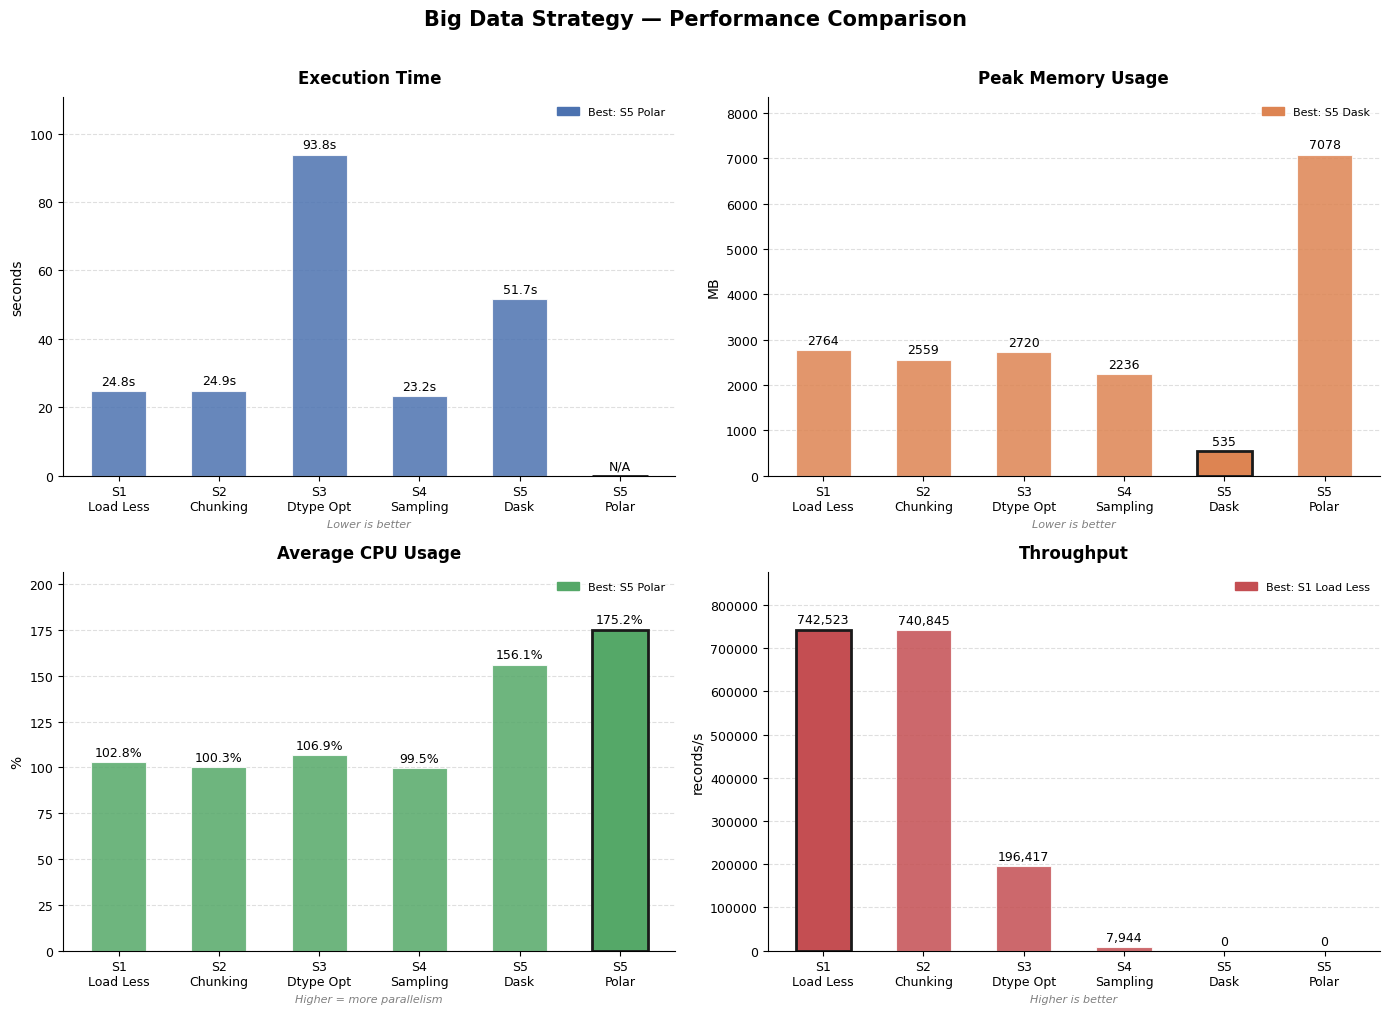

In [ ]:
summary = pd.concat([summary, polars_summary], ignore_index=True)
strategies  = summary['Strategy'].tolist()
short_labels = ['S1\nLoad Less', 'S2\nChunking', 'S3\nDtype Opt', 'S4\nSampling', 'S5\nDask', 'S5\nPolar']

metrics_cfg = [
    {
        'col'   : 'Exec Time (s)',
        'title' : 'Execution Time',
        'unit'  : 'seconds',
        'color' : '#4C72B0',
        'note'  : 'Lower is better',
        'lower' : True,
    },
    {
        'col'   : 'Peak Memory (MB)',
        'title' : 'Peak Memory Usage',
        'unit'  : 'MB',
        'color' : '#DD8452',
        'note'  : 'Lower is better',
        'lower' : True,
    },
    {
        'col'   : 'CPU Avg (%)',
        'title' : 'Average CPU Usage',
        'unit'  : '%',
        'color' : '#55A868',
        'note'  : 'Higher = more parallelism',
        'lower' : False,
    },
    {
        'col'   : 'Throughput (rec/s)',
        'title' : 'Throughput',
        'unit'  : 'records/s',
        'color' : '#C44E52',
        'note'  : 'Higher is better',
        'lower' : False,
    },
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Big Data Strategy — Performance Comparison', fontsize=15, fontweight='bold', y=1.01)
axes = axes.flatten()

for ax, cfg in zip(axes, metrics_cfg):
    values = summary[cfg['col']].fillna(0).tolist()
    bars   = ax.bar(short_labels, values, color=cfg['color'], alpha=0.85,
                    width=0.55, edgecolor='white', linewidth=0.8)

    # highlight best bar
    best_idx = int(np.argmin(values) if cfg['lower'] else np.argmax(values))
    bars[best_idx].set_edgecolor('#1a1a1a')
    bars[best_idx].set_linewidth(2)
    bars[best_idx].set_alpha(1.0)

    # value labels on each bar
    for bar, val in zip(bars, values):
        if val == 0:
            label = 'N/A'
        elif cfg['unit'] == 'records/s':
            label = f'{val/1e6:.2f}M' if val > 1e6 else f'{val:,.0f}'
        elif cfg['unit'] == 'seconds':
            label = f'{val:.1f}s'
        elif cfg['unit'] == 'MB':
            label = f'{val:.0f}'
        else:
            label = f'{val:.1f}%'

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(values) * 0.01,
            label,
            ha='center', va='bottom', fontsize=9, fontweight='500'
        )

    ax.set_title(cfg['title'], fontsize=12, fontweight='bold', pad=10)
    ax.set_ylabel(cfg['unit'], fontsize=10)
    ax.set_ylim(0, max(values) * 1.18)
    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

    # note + best marker
    best_patch = mpatches.Patch(color=cfg['color'], alpha=1.0,
                                label=f'Best: {short_labels[best_idx].replace(chr(10)," ")}')
    ax.legend(handles=[best_patch], fontsize=8, loc='upper right',
              framealpha=0.6, edgecolor='none')
    ax.set_xlabel(cfg['note'], fontsize=8, color='grey', style='italic')

plt.tight_layout()
plt.show()

## 10.2 Defining Function for benchmarking

In [ ]:
def benchmark(func, label, n_runs=2):

    load_times    = []
    process_times = []
    total_times   = []
    peak_mems     = []
    last_result   = None

    for run in range(n_runs):
        gc.collect()                            # clear previous run's memory

        tracemalloc.start()

        t_total_start = time.time()

        # LOAD phase
        t_load_start = time.time()
        data = func['load']()
        t_load_end   = time.time()

        # PROCESS phase (full compute)
        t_proc_start = time.time()
        result = func['compute'](data)
        t_proc_end   = time.time()

        t_total_end  = time.time()

        _, peak = tracemalloc.get_traced_memory()
        tracemalloc.stop()

        load_times.append(t_load_end    - t_load_start)
        process_times.append(t_proc_end - t_proc_start)
        total_times.append(t_total_end  - t_total_start)
        peak_mems.append(peak / 1e6)            # bytes → MB

        last_result = result
        del data, result
        gc.collect()

        print(f"  [{label}] Run {run+1}/{n_runs} — "
              f"total: {total_times[-1]:.2f}s  peak: {peak_mems[-1]:.1f} MB")

    return {
        'Library'            : label,
        'Load Time (s)'      : round(np.mean(load_times),    4),
        'Process Time (s)'   : round(np.mean(process_times), 4),
        'Total Time (s)'     : round(np.mean(total_times),   4),
        'Peak Memory (MB)'   : round(np.mean(peak_mems),     2),
        'Runs averaged'      : n_runs,
    }, last_result

## 10.3 Full Load with Pandas

In [ ]:
pandas_funcs = {
    'load': lambda: [pd.read_csv(f) for f in files],
    'compute': lambda chunks: pd.concat(chunks, ignore_index=True),
}

print("Running Pandas baseline...")
perf_pandas, result_pandas = benchmark(pandas_funcs, "Pandas")
print(f"  Shape: {result_pandas.shape}\n")
del result_pandas
gc.collect()

Running Pandas baseline...
  [Pandas] Run 1/2 — total: 22.15s  peak: 2653.5 MB
  [Pandas] Run 2/2 — total: 23.55s  peak: 2653.5 MB
  Shape: (18426380, 9)



0

## 10.4 Full Load with Dask

In [ ]:
dask_dtype_map = {
    'latitude'   : 'float32',
    'longitude'  : 'float32',
    'co_column'  : 'float32',
    'co_quality' : 'float32',
    'year'       : 'int16',
    'month'      : 'int16',    # int8 can cause issues in Dask, use int16 to be safe
    'day'        : 'int16',
    'day_of_week': 'int16',
}

dask_funcs = {
    'load'   : lambda: dd.read_csv(files, assume_missing=True, dtype=dask_dtype_map,),
    'compute': lambda ddf: ddf.compute().reset_index(drop=True),
}

print("Running Dask...")
perf_dask, result_dask = benchmark(dask_funcs, "Dask")
print(f"  Shape: {result_dask.shape}\n")
del result_dask
gc.collect()

Running Dask...
  [Dask] Run 1/2 — total: 117.21s  peak: 1621.8 MB
  [Dask] Run 2/2 — total: 118.44s  peak: 1621.7 MB
  Shape: (18426380, 9)



0

## 10.5 Full Load with Polars

In [ ]:
import polars as pl
import pandas as pd
import gc

polars_dtype_map = {
    "latitude"   : pl.Float32,
    "longitude"  : pl.Float32,
    "co_column"  : pl.Float32,
    "co_quality" : pl.Float32,
    "year"       : pl.Int16,
    "month"      : pl.Int16,
    "day"        : pl.Int16,
    "day_of_week": pl.Int16,
}

polars_funcs = {
    "load"   : lambda: pl.scan_csv(files, schema_overrides=polars_dtype_map, ignore_errors=True),
    "compute": lambda ldf: ldf.collect().to_pandas(),
}

print("Running Polars...")
perf_polars, result_polars = benchmark(polars_funcs, "Polars")
print(f"  Shape: {result_polars.shape}\n")
del result_polars
gc.collect()

Running Polars...
  [Polars] Run 1/2 — total: 10.68s  peak: 147.5 MB
  [Polars] Run 2/2 — total: 12.55s  peak: 147.5 MB
  Shape: (18426380, 9)



0

## 10.6 Summary Table

In [ ]:
import pandas as pd

# Construct the comparison dataframe using available metrics
comp_df = pd.DataFrame([perf_pandas, perf_dask, perf_polars])

print("\n" + "="*80)
print("SECTION 5 — COMPARATIVE ANALYSIS RESULTS")
print(f"Operation : Load + Full Dataset Compute   |   Runs averaged: {2}")
print("="*80)
print(comp_df.to_string(index=False))

# Highlight best per metric
print("\n── Best per metric ──")
for col in ["Load Time (s)", "Process Time (s)", "Total Time (s)", "Peak Memory (MB)"]:
    best_idx = comp_df[col].idxmin()
    print(f"  {col:<22}: {comp_df.loc[best_idx, 'Library']}  ({comp_df.loc[best_idx, col]})")


SECTION 5 — COMPARATIVE ANALYSIS RESULTS
Operation : Load + Full Dataset Compute   |   Runs averaged: 2
Library  Load Time (s)  Process Time (s)  Total Time (s)  Peak Memory (MB)  Runs averaged
 Pandas        21.7419            1.1073         22.8492           2653.48              2
   Dask         0.0610          117.7634        117.8244           1621.75              2
 Polars         0.0007           11.6148         11.6155            147.46              2

── Best per metric ──
  Load Time (s)         : Polars  (0.0007)
  Process Time (s)      : Pandas  (1.1073)
  Total Time (s)        : Polars  (11.6155)
  Peak Memory (MB)      : Polars  (147.46)


## 10.7 Visualization (Bar Chart / Table)

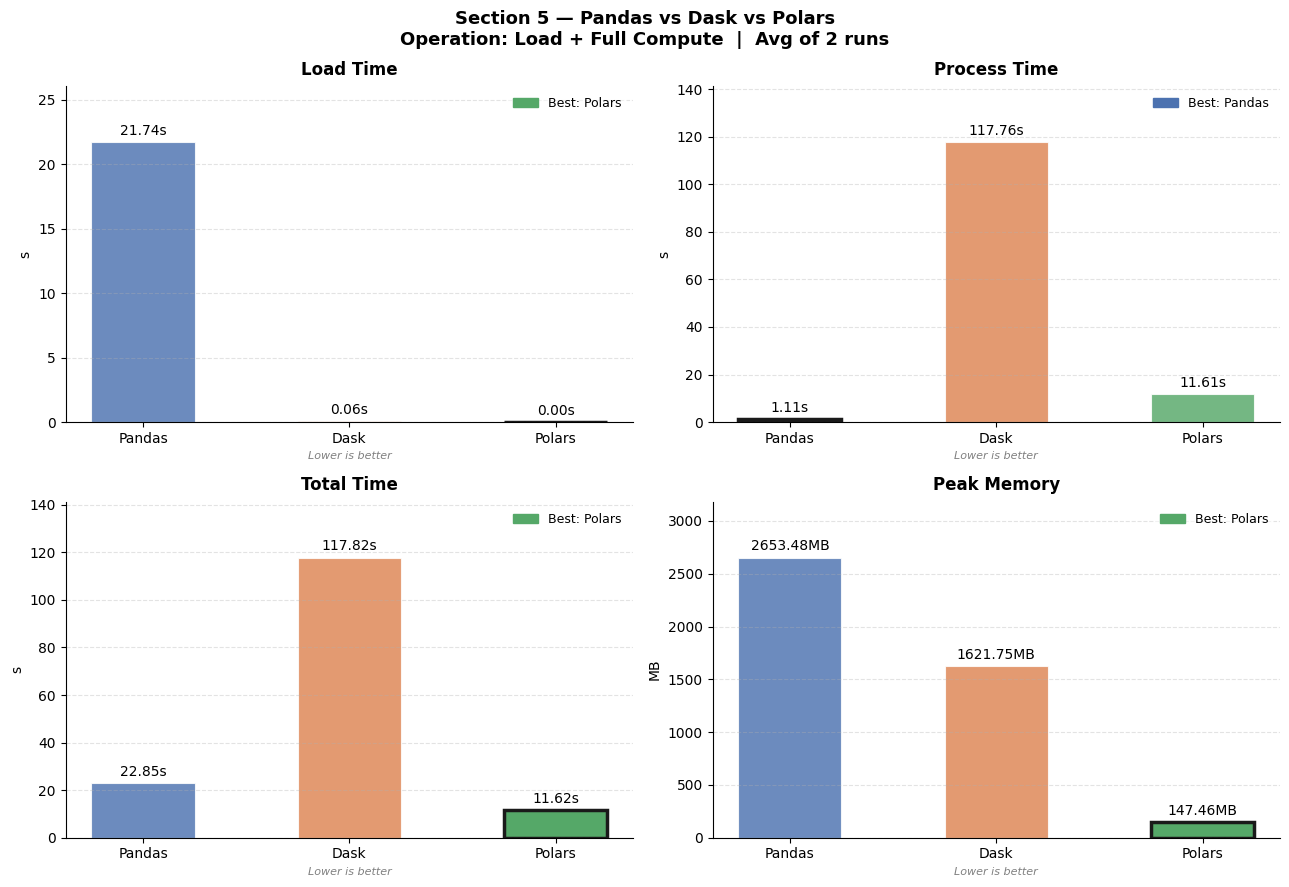

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

libraries = [p["Library"] for p in [perf_pandas, perf_dask, perf_polars]]
colors    = ["#4C72B0", "#DD8452", "#55A868"]

metrics_cfg = [
    {"key": "Load Time (s)",    "title": "Load Time",       "unit": "s",  "lower": True },
    {"key": "Process Time (s)", "title": "Process Time",    "unit": "s",  "lower": True },
    {"key": "Total Time (s)",   "title": "Total Time",      "unit": "s",  "lower": True },
    {"key": "Peak Memory (MB)", "title": "Peak Memory",     "unit": "MB", "lower": True },
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    f"Section 5 — Pandas vs Dask vs Polars\n"
    f"Operation: Load + Full Compute  |  Avg of {2} runs",
    fontsize=13, fontweight="bold"
)
axes = axes.flatten()

for ax, cfg in zip(axes, metrics_cfg):
    values   = [comp_df.loc[comp_df["Library"]==lib, cfg["key"]].values[0] for lib in libraries]
    best_idx = int(np.argmin(values))

    bars = ax.bar(libraries, values, color=colors, alpha=0.82, width=0.5, edgecolor="white", linewidth=0.8)
    bars[best_idx].set_edgecolor("#1a1a1a")
    bars[best_idx].set_linewidth(2.5)
    bars[best_idx].set_alpha(1.0)

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(values) * 0.015, f"{val:.2f}{cfg['unit']}", ha="center", va="bottom", fontsize=10, fontweight="500")

    ax.set_title(cfg["title"], fontsize=12, fontweight="bold", pad=8)
    ax.set_ylabel(cfg["unit"], fontsize=10)
    ax.set_ylim(0, max(values) * 1.2)
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35)
    ax.set_xlabel("Lower is better", fontsize=8, color="grey", style="italic")

    best_patch = mpatches.Patch(color=colors[best_idx], label=f"Best: {libraries[best_idx]}")
    ax.legend(handles=[best_patch], fontsize=9, loc="upper right", framealpha=0.5, edgecolor="none")

plt.tight_layout()
plt.show()